In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #11 Hypothesis testing

#1 generating data

In [17]:

N_trials=10**4
N_bins=100
trials_array=[]

for i in range(N_trials):
    ##3 bg cases with signal=0
    x_a_bg1=r.poisson(lam=0.1, size=N_bins)
    x_a_bg2=r.poisson(lam=10, size=N_bins)
    x_a_bg3=r.poisson(lam=1000, size=N_bins)

    ##2 signal cases
    x_b_sig1=np.zeros(N_bins)
    x_b_sig1[0]=100
    x_b_sig2=np.zeros(N_bins)
    x_b_sig2[0]=200
    x_b_bg=r.poisson(lam=1000, size=N_bins)

    trials_array.append([x_a_bg1, x_a_bg2, x_a_bg3, x_b_sig1+x_b_bg, x_b_sig2+x_b_bg])

trials_array

[[array([0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1]),
  array([11,  7, 14,  8, 11, 16,  4, 12,  9, 13, 16, 12, 18,  9,  7,  7,  6,
          9, 12, 11,  9, 14,  5,  7, 16, 12,  9,  9, 10,  7, 11,  9, 11, 10,
          9,  4,  8, 12,  7, 13,  9, 11, 14,  9, 13,  7,  9, 14, 12, 11,  3,
         10,  8, 12, 14, 14,  5,  7, 15, 13, 10, 10, 15,  5, 12, 10,  6, 10,
          9, 11,  7, 11,  9,  4, 13, 13,  6, 10,  7,  5,  7, 11,  4,  9, 16,
          9, 12,  8, 15,  6,  9,  7,  7,  9, 10, 15, 10,  9,  8, 12]),
  array([1010, 1011,  976, 1031, 1027,  988,  986, 1011, 1005, 1041,  991,
         1072, 1076,  997,  985,  973, 1037, 1016, 1003, 1041, 1016, 1066,
         1008, 1003, 1016, 1031, 1024,  986,  9

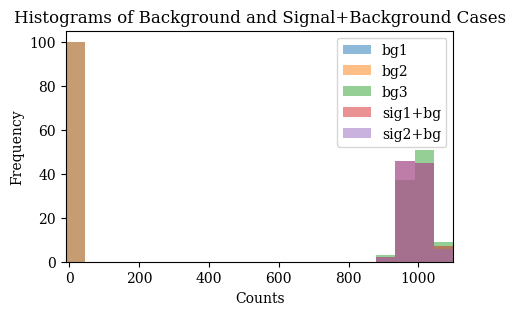

In [5]:
"""plotting the 5 cases in histograms"""

fig, ax=plt.subplots(1,1)
ax.hist(x_a_bg1, bins=20, range=(-10, 1100), alpha=0.5, label='bg1')
ax.hist(x_a_bg2, bins=20, range=(-10, 1100), alpha=0.5, label='bg2')
ax.hist(x_a_bg3, bins=20, range=(-10, 1100), alpha=0.5, label='bg3')
ax.hist(x_b_sig1+x_b_bg, bins=20, range=(-10, 1100), alpha=0.5, label='sig1+bg')
ax.hist(x_b_sig2+x_b_bg, bins=20, range=(-10, 1100), alpha=0.5, label='sig2+bg')
ax.set_xlim(-10, 1100)
ax.legend()
ax.set_xlabel('Counts')
ax.set_ylabel('Frequency')
ax.set_title('Histograms of Background and Signal+Background Cases')
plt.show()

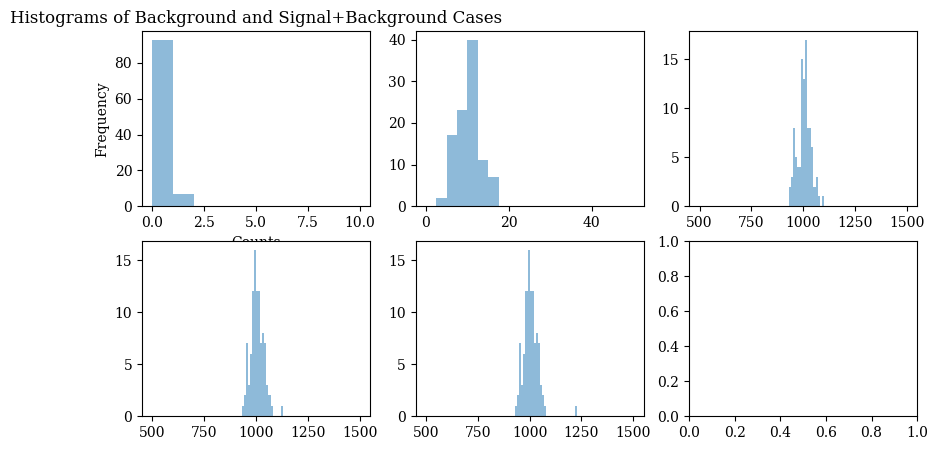

In [15]:
fig, ax=plt.subplots(2,3, figsize=(10,5))
ax[0,0].hist(x_a_bg1, bins=10, range=(0, 10), alpha=0.5, label='bg1')
ax[0,1].hist(x_a_bg2, bins=20, range=(0, 50), alpha=0.5, label='bg2')
ax[0,2].hist(x_a_bg3, bins=100, range=(500,1500), alpha=0.5, label='bg3')
ax[1,0].hist(x_b_sig1+x_b_bg, bins=100, range=(500,1500), alpha=0.5, label='sig1+bg')
ax[1,1].hist(x_b_sig2+x_b_bg, bins=100, range=(500,1500), alpha=0.5, label='sig2+bg')

ax[0,0].set_xlabel('Counts')
ax[0,0].set_ylabel('Frequency')
ax[0,0].set_title('Histograms of Background and Signal+Background Cases')
plt.show()

In [ ]:

def lambda_func(array,x1):
    n_tot=np.sum(array)
    n_bins=len(array)
    try:
        l=2*x1*np.log(n_bins/n_tot*x1)+2*(n_tot-x1)*np.log(n_bins/n_tot*(n_tot-x1)/(n_bins-1))
        if l == np.nan:
            raise ValueError("l is NaN")
    except:
        l=0
    return l

l=lambda_func(x_a_bg1, 10)
print(l)

nan


/tmp/ipykernel_10952/239432095.py:5: RuntimeWarning: invalid value encountered in log
  l=2*x1*np.log(n_bins/n_tot*x1)+2*(n_tot-x1)*np.log(n_bins/n_tot*(n_tot-x1)/(n_bins-1))


##2